The Normal Equation

In [4]:
#Test the Normal Equation
import numpy as np

In [5]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [6]:
import matplotlib.pyplot as plt

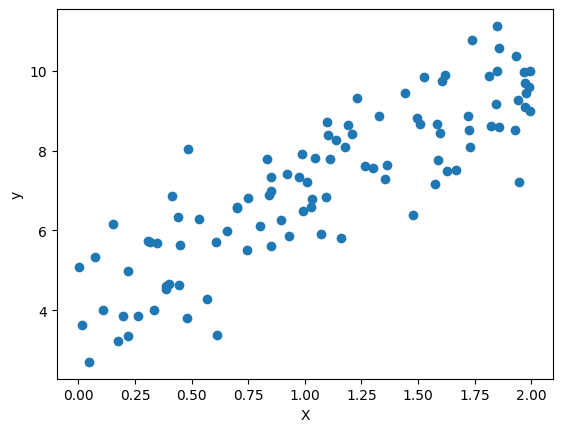

In [7]:
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [8]:
X_b = np.c_[np.ones((100, 1)), X]
X_b

array([[1.        , 0.74432256],
       [1.        , 1.06935579],
       [1.        , 0.04578903],
       [1.        , 1.3521386 ],
       [1.        , 0.91967972],
       [1.        , 1.59617924],
       [1.        , 1.3294549 ],
       [1.        , 0.75004111],
       [1.        , 1.26789871],
       [1.        , 1.84379904],
       [1.        , 1.57364837],
       [1.        , 0.44117409],
       [1.        , 0.56695795],
       [1.        , 1.71878996],
       [1.        , 0.38617176],
       [1.        , 1.2071535 ],
       [1.        , 1.47636465],
       [1.        , 1.97330423],
       [1.        , 0.41433687],
       [1.        , 1.19133361],
       [1.        , 0.85157459],
       [1.        , 1.09767296],
       [1.        , 1.73147675],
       [1.        , 1.0923005 ],
       [1.        , 1.99567229],
       [1.        , 0.84038124],
       [1.        , 1.60440196],
       [1.        , 1.92723082],
       [1.        , 0.83125801],
       [1.        , 1.93230419],
       [1.

In [9]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.11499808],
       [2.84341939]])

In [10]:
X_new = np.array([[0], [2]])
X_new

array([[0],
       [2]])

In [11]:
X_new_b = np.c_[np.ones((2, 1)), X_new]
X_new_b

array([[1., 0.],
       [1., 2.]])

In [12]:
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.11499808],
       [9.80183685]])

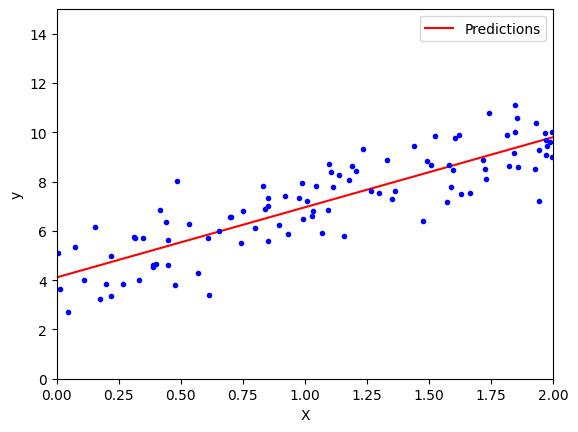

In [13]:
plt.plot(X_new, y_predict, 'r-', label='Predictions')
plt.plot(X, y, 'b.')
plt.axis([0, 2, 0, 15])
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [14]:
# Perform Linear Regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [15]:
lin_reg.fit(X,y)

LinearRegression()

In [16]:
lin_reg.intercept_, lin_reg.coef_

(array([4.11499808]), array([[2.84341939]]))

In [17]:
lin_reg.predict(X_new)

array([[4.11499808],
       [9.80183685]])

In [18]:
# Compare with the function Linear Regression is based on
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond = 1e-6)
theta_best_svd

array([[4.11499808],
       [2.84341939]])

In [19]:
# Compute the pseudoinverse directly
np.linalg.pinv(X_b).dot(y)

array([[4.11499808],
       [2.84341939]])

In [20]:
# Compute the Batch Gradient Descent
eta = 0.1 #learning rate
n_iterations = 1000
m = 100

In [21]:
theta = np.random.randn(2,1) #random initialization

In [22]:
for iteration in range (n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [23]:
theta

array([[4.11499808],
       [2.84341939]])

In [24]:
#Compute Stochastic Gradient Descent

n_epochs = 50 #rounds of iteration
t0, t1 = 5, 50 # learning schedule hyperparameters

In [25]:
def learning_schedule (t):
    return t0/(t + t1)

In [26]:
import numpy as np
theta = np.random.randn(2,1) #random initialization

In [27]:
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + 1)
        theta = theta - eta * gradients

In [28]:
theta

array([[4.15478186],
       [2.91210597]])

In [29]:
#Linear Regression using Stochastic GD
from sklearn.linear_model import SGDRegressor

In [30]:
sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

SGDRegressor(eta0=0.1, penalty=None)

In [31]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.15122835]), array([2.90191725]))

Polynomial Regression

In [32]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [33]:
X_rav = X.ravel()

Text(0, 0.5, 'y')

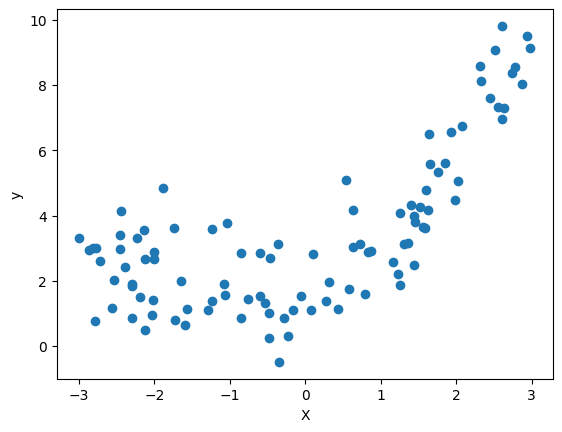

In [34]:
import matplotlib.pyplot as plt

plt.scatter (X, y)
plt.xlabel('X')
plt.ylabel('y')

In [35]:
#Transfor training data by adding the square of each feature (second-degree)
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

In [36]:
X[0]

array([1.97944234])

In [37]:
X_poly[0]

array([1.97944234, 3.91819198])

In [38]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [39]:
lin_reg.fit(X_poly, y)

LinearRegression()

In [40]:
lin_reg.intercept_, lin_reg.coef_

(array([1.80359547]), array([[0.96572892, 0.51533261]]))

That means the model is y = 0.44x^2 + 0.90x + 2.25

The original function was y = 0.5x^2 + x + 2 + gaussian noise

In [41]:
new_X = np.linspace(-3, 3, 100).reshape(100, 1)
new_X_poly = poly_features.fit_transform(new_X)

In [42]:
y_predict = lin_reg.predict(new_X_poly)

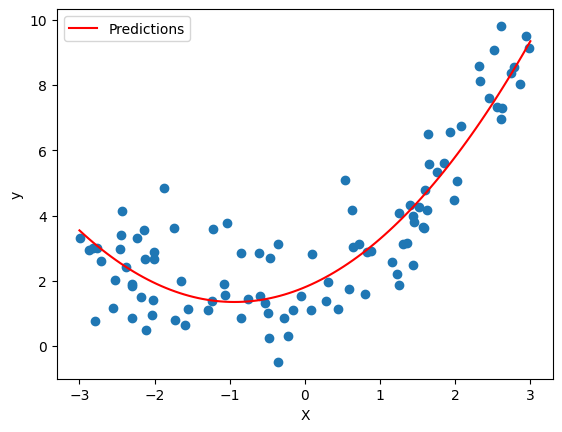

In [43]:
plt.scatter (X, y)
plt.plot(new_X, y_predict, '-', color='red', label='Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

Learning Curves

In [44]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

In [45]:
def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)
    train_errrors, val_errors = [], []

    for m in range (1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errrors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))
    
    plt.plot(np.sqrt(train_errrors), 'r-+', linewidth=2, label='train')
    plt.plot(np.sqrt(val_errors), 'b-', linewidth=3, label='val')
    plt.xlabel('Training set size')
    plt.ylabel('RMSE')
    plt.legend()

In [46]:
# Fit LinearRegression model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [47]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

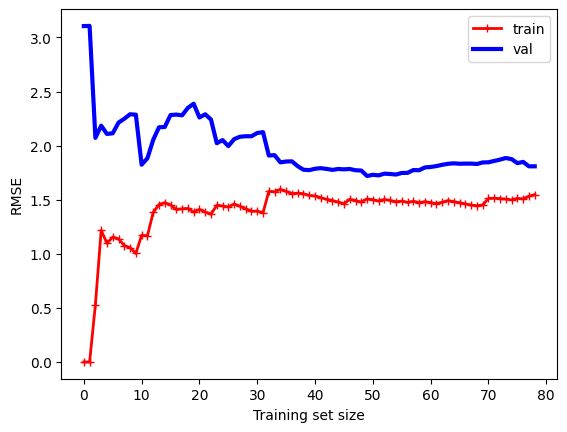

In [48]:
plot_learning_curves(lin_reg, X, y)

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

In [50]:
polynomial_regression = Pipeline([
    ('poly_features', PolynomialFeatures(degree=10, include_bias=False)),
    ('lin_reg', LinearRegression())
])

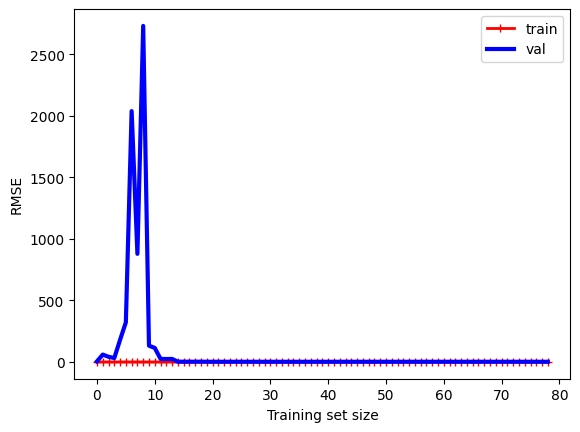

In [51]:
plot_learning_curves(polynomial_regression, X, y)

Regularized Linear Models

Ridge Regression

In [52]:
#Generate nonlinear data
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

In [53]:
from sklearn.linear_model import Ridge

In [54]:
ridge_reg = Ridge(alpha=1, solver='cholesky')

In [55]:
ridge_reg.fit(X, y)

Ridge(alpha=1, solver='cholesky')

In [56]:
ridge_reg.predict([[1.5]])

array([4.45144368])

In [57]:
from sklearn.linear_model import SGDRegressor

In [58]:
sgd_reg = SGDRegressor(penalty='l2')

In [59]:
sgd_reg.fit(X, y.ravel())

SGDRegressor()

In [60]:
sgd_reg.predict([[1.5]])

array([4.43155621])

Lasso Regression

In [61]:
from sklearn.linear_model import Lasso

In [62]:
lasso_reg = Lasso(alpha=0.1)

In [63]:
lasso_reg.fit(X, y)

Lasso(alpha=0.1)

In [64]:
lasso_reg.predict([[1.5]])

array([4.4001959])

In [65]:
from sklearn.linear_model import SGDRegressor

In [66]:
sgd_reg = SGDRegressor(penalty='l1')

In [67]:
sgd_reg.fit(X, y.ravel())

SGDRegressor(penalty='l1')

In [68]:
sgd_reg.predict([[1.5]])

array([4.43915059])

Elastic Net

In [69]:
from sklearn.linear_model import ElasticNet

In [70]:
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)

In [71]:
elastic_net.fit(X, y)

ElasticNet(alpha=0.1)

In [72]:
elastic_net.predict([[1.5]])

array([4.40636162])

Early Stopping

In [75]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler

In [76]:
#prepare the data
poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler())
])

In [87]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 4 + 3 * X + np.random.randn(100, 1)

In [88]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [89]:
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

In [90]:
sgd_reg = SGDRegressor(max_iter=1, tol=1e-5, warm_start=True,
                       penalty=None, learning_rate='constant', eta0=0.0005)

In [91]:
minimum_val_error = float('inf')
best_epoch = None
best_model = None

In [92]:
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:1608: ConvergenceWarning: Maximu